The simulation of the rods is taken from how it was done on [Hardo et al. 2024](https://www.nature.com/articles/s44303-024-00024-4#Sec33). For more details, please refer to [this notebook](https://github.com/georgeoshardo/projection_diffraction/blob/main/SI/SI_1/SI_1.ipynb) from their paper, as well as the [SyMBac](https://github.com/georgeoshardo/SyMBac?tab=readme-ov-file) documentation for installation instructions.

In [15]:
from SyMBac.drawing import raster_cell, convert_to_3D
from SyMBac.renderer import convolve_rescale, PSF_generator

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import matplotlib
from tifffile import imread,imwrite

from skimage.measure import regionprops_table
from scipy.stats import pearsonr 

import scienceplots
import random
from copy import deepcopy
from joblib import Parallel, delayed

from tqdm import tqdm
from glob import glob

In [2]:
pix_mic_conv=0.015
resize_amount = 1
def raster_membrane_cell_3d(raster_cell_length, raster_cell_width, raster_slice_amount = False):

    membrane_thickness = 0.1 #micron
    raster_membrane_thickness = membrane_thickness/pix_mic_conv * resize_amount
    cell_1 = raster_cell(length=round(raster_cell_length/2)*2, width=round(raster_cell_width/2)*2, separation=0)
    cell_2 = raster_cell(length=round((raster_cell_length - raster_membrane_thickness)/2)*2, width=round((raster_cell_width - raster_membrane_thickness)/2)*2, separation=0)

    cell_1_3d = convert_to_3D(cell_1)
    cell_2_3d = convert_to_3D(cell_2)

    
    pad_1 = int((cell_1_3d.shape[0] - cell_2_3d.shape[0])/2)
    pad_2 = int((cell_1_3d.shape[1] - cell_2_3d.shape[1])/2)
    pad_3 = int((cell_1_3d.shape[2] - cell_2_3d.shape[2])/2)

    cell_2_3d = np.pad(cell_2_3d, ((pad_1,pad_1), (pad_2, pad_2), (pad_3, pad_3)))
    
    cell_3d = cell_1_3d - cell_2_3d
    
    if raster_slice_amount:
        
        cell_3d = cell_3d[int(raster_slice_amount//2):-int(raster_slice_amount//2),:,:]
    
    return cell_3d

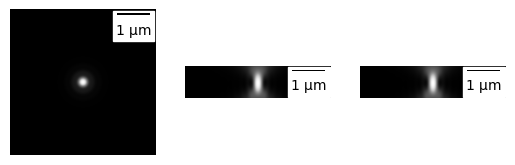

In [6]:
my_kernel = PSF_generator(
    radius = 150, 
    wavelength = 0.6, 
    NA=1.49, 
    n = 1.5, 
    resize_amount=1, 
    pix_mic_conv=0.015, 
    apo_sigma = 10, 
    mode="3d fluo", 
    condenser="Ph3", 
    z_height = 66,
    pz = 0.5,
    working_distance = 170
)
my_kernel.calculate_PSF()
my_kernel.kernel /= np.sum(my_kernel.kernel) # normalise so kernel sums to 1
my_kernel.plot_PSF()

In [9]:
widths = [0.4,0.5,0.6,0.8,1,1.2,1.4,1.6]

for w in widths:

    cells = []

    membrane_cell = np.pad(raster_membrane_cell_3d(4/pix_mic_conv, w/pix_mic_conv), ((1,1),(70,70),(70,70)))

    for i in range(5):
    
        
        coords = np.argwhere(membrane_cell)
        rng = np.random.default_rng()
        
        molecule_count = int(coords.shape[0]*0.9)

        random_coords = rng.choice(coords, molecule_count, replace=False)
        
        empty_cell = np.zeros_like(membrane_cell)

        for coord in random_coords:
            empty_cell[coord[0], coord[1], coord[2]] = 1
        
        conv_cell_3D = np.array([convolve_rescale(cell_layer.astype(float), kernel_layer, rescale_factor=1, rescale_int=False) for cell_layer, kernel_layer in tqdm(zip(empty_cell, my_kernel.kernel))])
        
        position = conv_cell_3D.shape[0]//2
        
        cell_slice = conv_cell_3D[position]
    
        cells.append(cell_slice*65535)
    
    stack = np.array(cells)

    w_ = str(w).replace('.','')
    
    imwrite(f'/Users/reyesmatte/Desktop/MEDUSSA_paper/FigS1/Simulated_stacks/{w_}_stack.tif',stack*10000)

    imwrite(f'/Users/reyesmatte/Desktop/MEDUSSA_paper/FigS1/Simulated_stacks/{w_}_membrane.tif',membrane_cell>0)

26it [00:00, 150.01it/s]
26it [00:00, 172.26it/s]
26it [00:00, 167.80it/s]
26it [00:00, 98.40it/s]
26it [00:00, 143.86it/s]
34it [00:00, 172.61it/s]
34it [00:00, 134.50it/s]
34it [00:00, 151.15it/s]
34it [00:00, 57.12it/s] 
34it [00:00, 112.04it/s]
40it [00:00, 170.88it/s]
40it [00:00, 112.34it/s]
40it [00:00, 172.32it/s]
40it [00:00, 176.23it/s]
40it [00:00, 169.97it/s]
54it [00:00, 162.40it/s]
54it [00:00, 149.05it/s]
54it [00:00, 156.77it/s]
54it [00:00, 149.83it/s]
54it [00:00, 131.35it/s]
66it [00:00, 152.95it/s]
66it [00:00, 161.84it/s]
66it [00:00, 161.85it/s]
66it [00:00, 163.67it/s]
66it [00:00, 160.24it/s]
66it [00:00, 144.74it/s]
66it [00:00, 142.85it/s]
66it [00:00, 148.56it/s]
66it [00:00, 151.83it/s]
66it [00:00, 151.70it/s]
66it [00:00, 145.79it/s]
66it [00:00, 97.76it/s] 
66it [00:00, 143.93it/s]
66it [00:00, 146.40it/s]
66it [00:00, 154.57it/s]
66it [00:00, 123.98it/s]
66it [00:00, 138.17it/s]
66it [00:00, 141.09it/s]
66it [00:00, 122.17it/s]
66it [00:00, 137.42it/s]


In [50]:
pixsize = 0.065

imgs = sorted(glob('/Users/reyesmatte/Desktop/MEDUSSA_paper/FigS1/Simulated_stacks/Labelled Image*'))

x,y = [],[]

for i in imgs:
    x_ = int(i.split('_')[-1].split('.')[0])/10

    df = pd.DataFrame(regionprops_table(imread(i)))
    y_ = np.median(np.array(df['bbox-3']-df['bbox-1'])*pixsize)
    
    x.append(x_)
    y.append(y_)

df = pd.DataFrame()
df.insert(0,'True width',x)
df.insert(1,'Measured width',y)
df.to_csv('/Users/reyesmatte/Desktop/MEDUSSA_paper/Raw_data/FigS1.csv')

In [52]:
df = pd.read_csv('https://github.com/OReyesMatte/MEDUSSA/raw/refs/heads/main/Raw_Data/FigS1.csv')
x,y = np.array(df['True width']),np.array(df['Measured width'])

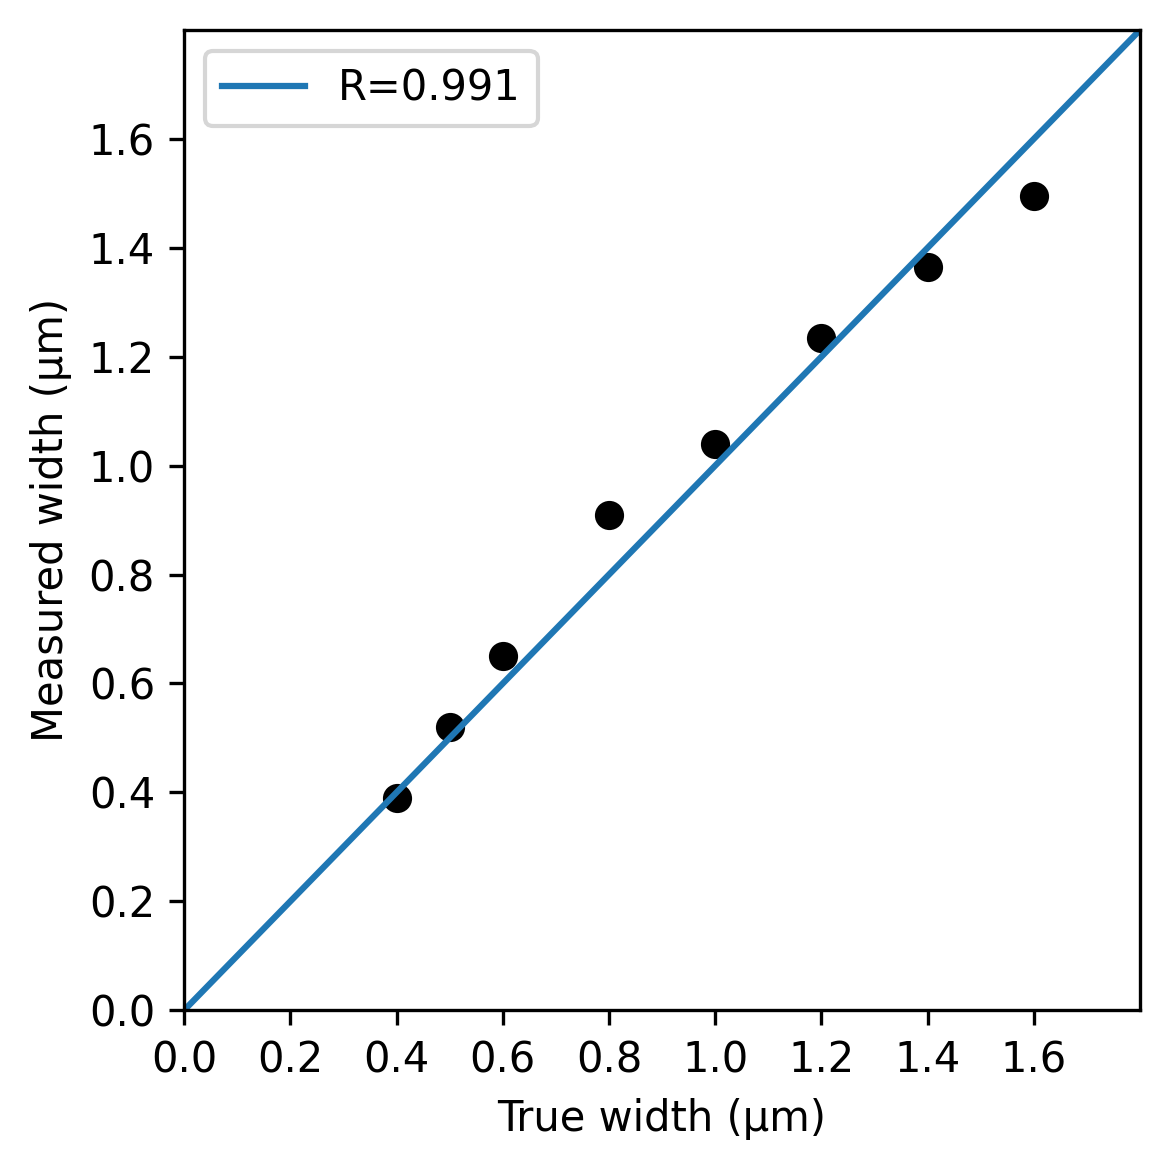

In [54]:
r,p = pearsonr(x,y)

fig,ax = plt.subplots(dpi=300,figsize=(4,4))

ax.scatter(x,y,c='k')
ax.plot([0,1.8],[0,1.8], label = f'R={r:.3f}')
ax.set_xlim(0,1.8)
ax.set_ylim(0,1.8)
ax.set_xlabel('True width (µm)')
ax.set_ylabel('Measured width (µm)')
ax.set_xticks([0,0.2,0.4,0.6,0.8,1.0,1.2,1.4,1.6])
ax.set_yticks([0,0.2,0.4,0.6,0.8,1.0,1.2,1.4,1.6])
ax.legend()

fig.tight_layout()
#fig.savefig('/Users/reyesmatte/Desktop/MEDUSSA_paper/FigS1/symbac_results_scaled.png')